## 1 - Data Analysis & Extraction

El objetivo principal es extraer y analizar los datos de la base de datos ***MIMIC-IV***
El primer paso es analizar de que tipo de datos disponemos, de primeras se puede observar que el formato de los archivos es `csv.gz`, el formato `gz` indica que es un archivo comprimido, y previamente tiene el formato `csv`, por lo tanto se puede llegar a suponer que es un archivo csv comprimido. La librería pandas ayudará a leer los archivos csv comprimidos directamente sin descompresión manual.

Lo principal es importar las librerías que serán necesarias para analizar y procesar estos datos

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

In [2]:
# Configuracion global
BASE_DATA_DIR = '../data' # Directorio raíz del dataset MIMIC-IV
OUTPUT_DIR = '../data/processed' # Directorio de salida para artefactos

PREDICTION_HORIZON_H = 6 # Horizonte de predicción rodante (horas)
MIN_STAY_HOURS = 6 # Cobertura mínima de horas por estancia

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

Con las librerías requeridas cargadas ya se pueden importar y empezar a usar los datos, aunque antes hay que entender cómo están estructurados y qué relación hay entre diferentes archivos `csv`.

Según la documentación de **MIMIC-IV** tenemos dos directorios principales:

- **hosp**: Contiene **546,028** registros únicos de hospitalizaciones para **223,452** individuos únicos. Estos datos se dividen en cuatro categorías principales:
    - **Información Básica y Logística**: Incluye los datos personales de los pacientes (edad, género, etc), y registra cuando entra y sale un paciente de una unidad en concreto.
    - **Datos Clínicos y de Laboratorio**: Contiene eventos registrados en un laboratorio, como por ejemplo resultados de análisis de sangre, orina, etc.
    - **Medicamentos**: Contiene las recetas prescritas por los médicos, también incluye un registro de cuando y como se ha administrado el medicamiento.
    - **Facturación y Diagnósticos**: Incluye los datos que indican los códigos de los diagnósticos y procedimientos realizados.

- **icu**: Contiene **94,458** registros de estancias de pacientes en la UCI. Estos datos se estructuran de forma que hay una tabla "estancias" central que se conecta con otras tablas de eventos, estas tablas registran todos los sucesos de un paciente minuto a minuto.

Con este conocimiento solo queda conocer los campos que enlazan las diferentes tablas, los campos más importantes son:

- `subject_id`: Identificador único del paciente
- `hadm_id`: Identificador único de admisión hospitalaria (un paciente puede tener más de una admisión)
- `stay_id`: Identificador único de estancia en la UCI (una admisión puede tener varias estancias)

In [3]:
ID_SUBJECT = 'subject_id'
ID_ADMISION = 'hadm_id'
ID_STAY = 'stay_id'

### Definición de Sepsis-3 en lugar de códigos ICD

El enfoque anterior se basaba en códigos de facturación (ICD), que suelen ser imprecisos y se registran al final de la estancia. 
Para un sistema de alerta temprana es crítico disponer de una etiqueta de sepsis que se alinee con el **momento real del deterioro clínico**.

Por ello, se adopta la definición **Sepsis-3**:

1. **Sospecha de Infección (SI)**: presencia de un cultivo microbiológico (`microbiologyevents`) 
y administración de un antibiótico sistémico (`prescriptions`) dentro de una ventana de ±72 horas.

2. **Cambio agudo en SOFA ≥ 2**: para cada estancia con SI, se calcula el score SOFA de forma horaria 
a partir de variables fisiológicas (labs, signos vitales, vasopresores, ventilación, diuresis). 
El **onset** de sepsis se define como la primera hora en la que el SOFA supera en al menos 2 puntos 
el valor mínimo basal previo a la sospecha de infección.

Este método proporciona un **onset temporal mucho más preciso** que fijarlo en el `intime`, 
permitiendo extraer la ventana de 48h previa al deterioro real del paciente.

In [4]:
# Cargamos diagnoses_icd (se mantiene para el cálculo del índice de Charlson más adelante)
diagnoses = pd.read_csv(f'{BASE_DATA_DIR}/hosp/diagnoses_icd.csv.gz')
print(diagnoses.shape)
print(diagnoses.dtypes)
print(diagnoses.head())


(6364488, 5)
subject_id     int64
hadm_id        int64
seq_num        int64
icd_code         str
icd_version    int64
dtype: object
   subject_id   hadm_id  seq_num icd_code  icd_version
0    10000032  22595853        1     5723            9
1    10000032  22595853        2    78959            9
2    10000032  22595853        3     5715            9
3    10000032  22595853        4    07070            9
4    10000032  22595853        5      496            9


In [5]:
# ---------------------------------- Sepsis-3: Sospecha de Infección (SI) ----------------------------------
# Definición clínica: antibiótico + cultivo en un intervalo de ±72 horas.
# Referencia: Seymour et al. (2016) — Assessment of Clinical Criteria for Sepsis.

microbiology = pd.read_csv(
    f'{BASE_DATA_DIR}/hosp/microbiologyevents.csv.gz',
    usecols=['subject_id', 'hadm_id', 'charttime', 'spec_itemid']
)
prescriptions = pd.read_csv(
    f'{BASE_DATA_DIR}/hosp/prescriptions.csv.gz',
    usecols=['subject_id', 'hadm_id', 'starttime', 'drug']
)

microbiology['charttime'] = pd.to_datetime(microbiology['charttime'])
prescriptions['starttime'] = pd.to_datetime(prescriptions['starttime'])

# Antibióticos sistémicos de amplio espectro
ANTIBIOTIC_KEYWORDS = [
    'vancomycin', 'piperacillin', 'tazobactam', 'meropenem', 'imipenem',
    'ceftriaxone', 'cefepime', 'aztreonam', 'ciprofloxacin', 'levofloxacin',
    'metronidazole', 'ceftazidime', 'ampicillin', 'gentamicin', 'amoxicillin',
    'clavulanate', 'ertapenem', 'linezolid', 'daptomycin', 'azithromycin',
    'cefotaxime', 'ticarcillin', 'clindamycin', 'cefoxitin', 'trimethoprim',
    'sulfamethoxazole', 'penicillin', 'tobramycin', 'amikacin'
]
abx_mask = prescriptions['drug'].str.lower().str.contains('|'.join(ANTIBIOTIC_KEYWORDS), na=False)
abx = prescriptions[abx_mask].copy()

# Primer evento por admisión
first_abx = abx.groupby('hadm_id')['starttime'].min().reset_index(name='first_abx_time')
first_culture = microbiology.groupby('hadm_id')['charttime'].min().reset_index(name='first_culture_time')

# Ventana de sospecha: ±72h entre antibiótico y cultivo
suspected = first_abx.merge(first_culture, on='hadm_id', how='inner')
suspected['time_diff_h'] = (
    (suspected['first_abx_time'] - suspected['first_culture_time']).dt.total_seconds().abs() / 3600
)
suspected_inf_hadm = suspected[suspected['time_diff_h'] <= 72]['hadm_id'].unique()

print(f'Admisiones con sospecha de infección (SI): {len(suspected_inf_hadm):,}')


Admisiones con sospecha de infección (SI): 117,435


Los códigos ICD tienen limitaciones conocidas: son códigos de facturación, a menudo imprecisos, 
y se registran al alta hospitalaria. Para un sistema de alerta temprana es fundamental basar 
la etiqueta en criterios clínicos que reflejen el momento real del deterioro.

Por ello, se abandona el enfoque ICD explícito + algoritmo Angus y se adopta directamente 
la definición **Sepsis-3** en el pipeline.

In [6]:
# ---------------------------------- Sepsis-3: Cálculo de SOFA y Onset ----------------------------------
# Objetivo: para cada estancia UCI con sospecha de infección, calcular SOFA horario,
# establecer un baseline y detectar el momento exacto en que SOFA sube ≥ 2 puntos.

# Cargar icustays (necesario para delimitar el periodo de cada estancia)
icustays = pd.read_csv(f'{BASE_DATA_DIR}/icu/icustays.csv.gz')
icustays['intime'] = pd.to_datetime(icustays['intime'])
icustays['outtime'] = pd.to_datetime(icustays['outtime'])

# Filtrar solo estancias de admisiones con sospecha de infección
candidate_icu = icustays[icustays['hadm_id'].isin(suspected_inf_hadm)].copy()
candidate_stay_ids = set(candidate_icu['stay_id'].unique())
print(f'Estancias UCI candidatas (con SI): {len(candidate_stay_ids):,}')

# ── Diccionarios de itemids para SOFA ──
d_items = pd.read_csv(f'{BASE_DATA_DIR}/icu/d_items.csv.gz')
d_labitems = pd.read_csv(f'{BASE_DATA_DIR}/hosp/d_labitems.csv.gz')

# Vitales
map_items = set(d_items[d_items['label'] == 'Arterial Blood Pressure mean']['itemid'])
gcs_motor_items = set(d_items[d_items['label'] == 'GCS - Motor Response']['itemid'])
gcs_verbal_items = set(d_items[d_items['label'] == 'GCS - Verbal Response']['itemid'])
gcs_eye_items = set(d_items[d_items['label'].str.contains('GCS - Eye Opening', case=False, na=False)]['itemid'])
peep_items = set(d_items[d_items['label'] == 'PEEP set']['itemid'])
fio2_items = set(d_items[d_items['label'].str.contains('FiO2|Inspired O2 Fraction', case=False, na=False)]['itemid'])

# Laboratorio
plt_items = set(d_labitems[(d_labitems['label'] == 'Platelet Count') & (d_labitems['fluid'] == 'Blood')]['itemid'])
bili_items = set(d_labitems[(d_labitems['label'] == 'Bilirubin, Total') & (d_labitems['fluid'] == 'Blood')]['itemid'])
creat_items = set(d_labitems[(d_labitems['label'] == 'Creatinine') & (d_labitems['fluid'] == 'Blood')]['itemid'])
po2_items = set(d_labitems[(d_labitems['label'] == 'pO2') & (d_labitems['fluid'] == 'Blood')]['itemid'])

# Procedimientos / inputs / outputs
vaso_items = {221906, 221662, 221289, 222315, 221749, 221653}
vent_items = {225792, 225794}
urine_items = {226559, 226560, 226561, 226584, 226563, 226564, 226565}

# ── Función para cargar eventos en chunks filtrando por stay_id / subject_id ──
def load_events_filtered(path, ids, cols, id_col='stay_id', time_col='charttime', val_col='valuenum', chunksize=500_000):
    chunks = []
    for chunk in pd.read_csv(path, usecols=cols, chunksize=chunksize):
        f = chunk[chunk[id_col].isin(ids)]
        if len(f):
            f[time_col] = pd.to_datetime(f[time_col])
            if val_col and val_col in f.columns:
                f[val_col] = pd.to_numeric(f[val_col], errors='coerce')
            chunks.append(f)
    return pd.concat(chunks, ignore_index=True) if chunks else pd.DataFrame()

candidate_subject_ids = set(candidate_icu['subject_id'].unique())

print('Cargando chartevents (SOFA)...')
chart_sofa = load_events_filtered(
    f'{BASE_DATA_DIR}/icu/chartevents.csv.gz',
    candidate_stay_ids,
    ['stay_id', 'charttime', 'itemid', 'valuenum']
)
print(f'  chartevents SOFA: {chart_sofa.shape}')

print('Cargando labevents (SOFA)...')
lab_sofa = load_events_filtered(
    f'{BASE_DATA_DIR}/hosp/labevents.csv.gz',
    candidate_subject_ids,
    ['subject_id', 'hadm_id', 'charttime', 'itemid', 'valuenum'],
    id_col='subject_id'
)
stay_hadm = candidate_icu[['stay_id', 'hadm_id']].drop_duplicates()
lab_sofa = lab_sofa.merge(stay_hadm, on='hadm_id', how='inner')
print(f'  labevents SOFA: {lab_sofa.shape}')

print('Cargando inputevents (vasopresores)...')
input_sofa = load_events_filtered(
    f'{BASE_DATA_DIR}/icu/inputevents.csv.gz',
    candidate_stay_ids,
    ['stay_id', 'starttime', 'endtime', 'itemid', 'rate'],
    time_col='starttime', val_col='rate'
)
input_sofa = input_sofa[input_sofa['itemid'].isin(vaso_items)]
input_sofa['endtime'] = pd.to_datetime(input_sofa['endtime'])
print(f'  vasopresores SOFA: {input_sofa.shape}')

print('Cargando outputevents (gasto urinario)...')
output_sofa = load_events_filtered(
    f'{BASE_DATA_DIR}/icu/outputevents.csv.gz',
    candidate_stay_ids,
    ['stay_id', 'charttime', 'itemid', 'value'],
    val_col='value'
)
output_sofa = output_sofa[output_sofa['itemid'].isin(urine_items)]
print(f'  gasto urinario SOFA: {output_sofa.shape}')

print('Cargando procedureevents (ventilación)...')
proc_sofa = load_events_filtered(
    f'{BASE_DATA_DIR}/icu/procedureevents.csv.gz',
    candidate_stay_ids,
    ['stay_id', 'starttime', 'endtime', 'itemid'],
    time_col='starttime', val_col=None
)
proc_sofa = proc_sofa[proc_sofa['itemid'].isin(vent_items)]
proc_sofa['endtime'] = pd.to_datetime(proc_sofa['endtime'])
print(f'  ventilación SOFA: {proc_sofa.shape}')


# ── Función VECTORIZADA para calcular SOFA horario ──
# Corrección del bug de rendimiento: la versión original usaba bucles
# O(estancias × horas × eventos_por_estancia), causando tiempos de ejecución
# de horas. Esta versión pre-agrupa por stay_id y usa resample+rolling,
# reduciendo la complejidad a O(estancias × eventos).
def compute_hourly_sofa_fast(candidate_icu, chart, lab, inputs, outputs, procedures):
    # Pre-agrupar por stay_id: lookup O(1) en lugar de escaneo O(n) por estancia
    chart_g = dict(tuple(chart.groupby('stay_id')))
    lab_g   = dict(tuple(lab.groupby('stay_id')))
    inp_g   = dict(tuple(inputs.groupby('stay_id')))
    out_g   = dict(tuple(outputs.groupby('stay_id')))
    proc_g  = dict(tuple(procedures.groupby('stay_id')))

    results = []

    for _, stay in candidate_icu.iterrows():
        sid     = stay['stay_id']
        intime  = stay['intime']
        outtime = stay['outtime']
        los_h   = int((outtime - intime).total_seconds() / 3600) + 1
        if los_h < 1:
            continue

        hours = pd.date_range(start=intime, periods=los_h, freq='h')
        h_idx = pd.RangeIndex(los_h)

        c   = chart_g.get(sid)
        l   = lab_g.get(sid)
        inp = inp_g.get(sid)
        out = out_g.get(sid)
        pr  = proc_g.get(sid)

        def _to_hidx(df, time_col):
            """Convierte tiempos de eventos a índices enteros de hora relativos a intime."""
            if df is None or df.empty:
                return None
            d = df.copy()
            d['_h'] = np.floor((d[time_col] - intime).dt.total_seconds() / 3600).astype(int)
            r = d[(d['_h'] >= 0) & (d['_h'] < los_h)]
            return r if not r.empty else None

        def _lab_roll(items, window_h, fn='max'):
            """Agrega lab events por cubo horario y aplica ventana rodante."""
            if l is None:
                return pd.Series(np.nan, index=h_idx)
            sub = l[l['itemid'].isin(items)][['charttime', 'valuenum']].dropna()
            if sub.empty:
                return pd.Series(np.nan, index=h_idx)
            sub = _to_hidx(sub, 'charttime')
            if sub is None:
                return pd.Series(np.nan, index=h_idx)
            s = sub.groupby('_h')['valuenum'].agg(fn).reindex(h_idx)
            return s.rolling(window_h, min_periods=1).agg(fn)

        def _chart_roll(items, window_h, fn='max'):
            """Agrega chart events por cubo horario y aplica ventana rodante."""
            if c is None:
                return pd.Series(np.nan, index=h_idx)
            sub = c[c['itemid'].isin(items)][['charttime', 'valuenum']].dropna()
            if sub.empty:
                return pd.Series(np.nan, index=h_idx)
            sub = _to_hidx(sub, 'charttime')
            if sub is None:
                return pd.Series(np.nan, index=h_idx)
            s = sub.groupby('_h')['valuenum'].agg(fn).reindex(h_idx)
            return s.rolling(window_h, min_periods=1).agg(fn)

        def _interval_flag(df, start_col, end_col):
            """Flag binario: True en cubos horarios donde algún intervalo está activo."""
            flags = pd.Series(False, index=h_idx)
            if df is None or df.empty:
                return flags
            for _, ev in df.iterrows():
                s_h = max(0, int(np.floor((ev[start_col] - intime).total_seconds() / 3600)))
                e_h = min(los_h - 1, int(np.ceil((ev[end_col] - intime).total_seconds() / 3600)))
                if s_h <= e_h:
                    flags.iloc[s_h:e_h + 1] = True
            return flags

        # ── Respiratorio (P/F ratio + ventilación mecánica) ──
        po2  = _lab_roll(po2_items, 6, 'max')
        fio2 = _chart_roll(fio2_items, 6, 'max')
        vent = _interval_flag(pr, 'starttime', 'endtime')
        pfr  = po2 / fio2

        resp = np.where(
            vent & pfr.notna(),
            np.select([pfr < 100, pfr < 200, pfr < 300, pfr < 400], [4, 3, 2, 1], 0),
            np.where(~vent & pfr.notna(), (pfr < 400).astype(int),
            np.where(vent.values, 2, 0))
        )
        resp = pd.Series(resp, index=h_idx)

        # ── Coagulación (plaquetas, ventana 24h) ──
        plt_min = _lab_roll(plt_items, 24, 'min')
        coag = pd.Series(
            np.select([plt_min < 20, plt_min < 50, plt_min < 100, plt_min < 150], [4, 3, 2, 1], 0),
            index=h_idx
        )
        coag[plt_min.isna()] = 0

        # ── Hepático (bilirrubina, ventana 24h) ──
        bili_max = _lab_roll(bili_items, 24, 'max')
        liver = pd.Series(
            np.select([bili_max >= 12, bili_max >= 6, bili_max >= 2, bili_max >= 1.2], [4, 3, 2, 1], 0),
            index=h_idx
        )
        liver[bili_max.isna()] = 0

        # ── Cardiovascular (MAP arterial + vasopresores) ──
        map_min = _chart_roll(map_items, 1, 'min')
        vaso    = _interval_flag(inp, 'starttime', 'endtime')
        cardio  = pd.Series(
            np.where(vaso, 3, np.where(map_min < 70, 1, 0)),
            index=h_idx
        )
        cardio[~vaso & map_min.isna()] = 0

        # ── SNC (GCS total, ventana 6h) ──
        gcs_m = _chart_roll(gcs_motor_items,  6, 'max')
        gcs_v = _chart_roll(gcs_verbal_items, 6, 'max')
        gcs_e = _chart_roll(gcs_eye_items,    6, 'max').fillna(4.0)
        gcs   = gcs_m + gcs_v + gcs_e
        neuro = pd.Series(
            np.select([gcs < 6, gcs < 10, gcs < 13, gcs < 15], [4, 3, 2, 1], 0),
            index=h_idx
        )
        neuro[gcs_m.isna() | gcs_v.isna()] = 0

        # ── Renal (creatinina + diuresis 24h) ──
        creat_max = _lab_roll(creat_items, 24, 'max')
        urine_24  = pd.Series(np.nan, index=h_idx)
        if out is not None and not out.empty:
            u = _to_hidx(out[['charttime', 'value']].copy(), 'charttime')
            if u is not None:
                u['value'] = pd.to_numeric(u['value'], errors='coerce')
                u = u.groupby('_h')['value'].sum().reindex(h_idx)
                urine_24 = u.rolling(24, min_periods=1).sum()

        has_urine = urine_24.notna()
        renal = pd.Series(np.select([
            has_urine & (urine_24 < 200),
            has_urine & (urine_24 < 500),
            creat_max.notna() & (creat_max >= 5.0),
            creat_max.notna() & (creat_max >= 3.5),
            creat_max.notna() & (creat_max >= 2.0),
        ], [4, 3, 3, 2, 1], 0), index=h_idx)

        sofa = resp + coag + liver + cardio + neuro + renal

        results.append(pd.DataFrame({
            'stay_id':        sid,
            'hour':           hours,
            'h_since_intime': h_idx.values.astype(float),
            'sofa':           sofa.values,
        }))

    return pd.concat(results, ignore_index=True) if results else pd.DataFrame()


print('Calculando SOFA horario para estancias candidatas...')
sofa_hourly = compute_hourly_sofa_fast(candidate_icu, chart_sofa, lab_sofa, input_sofa, output_sofa, proc_sofa)
print(f'Registros SOFA horario calculados: {len(sofa_hourly):,}')

# ── Detectar Sepsis Onset (SOFA ≥ baseline + 2) ──
culture_time_map = first_culture.set_index('hadm_id')['first_culture_time'].to_dict()
candidate_icu['suspected_time'] = candidate_icu['hadm_id'].map(culture_time_map)

onset_records = []
for sid, grp in sofa_hourly.groupby('stay_id'):
    stay_info = candidate_icu[candidate_icu['stay_id'] == sid].iloc[0]
    t_si = stay_info['suspected_time']
    if pd.isna(t_si):
        continue
    baseline_sofa = grp[grp['hour'] <= t_si]['sofa'].min()
    if pd.isna(baseline_sofa):
        baseline_sofa = 0
    onset_candidates = grp[grp['hour'] >= t_si]
    onset_row = onset_candidates[onset_candidates['sofa'] >= (baseline_sofa + 2)]
    if len(onset_row) == 0:
        continue
    onset_time = onset_row.iloc[0]['hour']
    onset_sofa = onset_row.iloc[0]['sofa']
    onset_records.append({
        'stay_id': sid,
        'hadm_id': stay_info['hadm_id'],
        'subject_id': stay_info['subject_id'],
        'intime': stay_info['intime'],
        'outtime': stay_info['outtime'],
        'suspected_time': t_si,
        'baseline_sofa': baseline_sofa,
        'sepsis_onset': onset_time,
        'onset_sofa': onset_sofa,
    })

final_cohort = pd.DataFrame(onset_records)
print(f'Estancias con Sepsis-3 (SI + ΔSOFA≥2): {len(final_cohort):,}')
print(final_cohort[['baseline_sofa', 'onset_sofa']].describe())


Estancias UCI candidatas (con SI): 47,588
Cargando chartevents (SOFA)...
  chartevents SOFA: (281634960, 4)
Cargando labevents (SOFA)...
  labevents SOFA: (34330617, 6)
Cargando inputevents (vasopresores)...
  vasopresores SOFA: (573080, 5)
Cargando outputevents (gasto urinario)...
  gasto urinario SOFA: (2657012, 4)
Cargando procedureevents (ventilación)...
  ventilación SOFA: (24256, 4)
Calculando SOFA horario para estancias candidatas...
Registros SOFA horario calculados: 5,203,081
Estancias con Sepsis-3 (SI + ΔSOFA≥2): 37,377
       baseline_sofa    onset_sofa
count   37377.000000  37377.000000
mean        1.376783      6.411938
std         2.763184      3.879769
min         0.000000      2.000000
25%         0.000000      3.000000
50%         0.000000      5.000000
75%         1.000000      9.000000
max        19.000000     22.000000


La cohorte de sepsis ya no se basa en diagnósticos ICD, sino en la definición clínica Sepsis-3. 
El siguiente paso es cargar las tablas auxiliares (`admissions`, `icustays`, `transfers`) 
que se seguirán utilizando en pasos posteriores (por ejemplo, para comorbilidades y demografía).

A continuación se cargan también las tablas de diccionario (`d_items`, `d_labitems`) 
que se usarán para extraer las variables del modelo.

In [7]:
admissions = pd.read_csv(f'{BASE_DATA_DIR}/hosp/admissions.csv.gz')
transfers = pd.read_csv(f'{BASE_DATA_DIR}/hosp/transfers.csv.gz')
icustays = pd.read_csv(f'{BASE_DATA_DIR}/icu/icustays.csv.gz')

print('-------------------------------- Tabla admissions --------------------------------')
print(admissions.shape)
print(admissions.dtypes)

print('-------------------------------- Tabla icustays --------------------------------')
print(icustays.shape)
print(icustays.dtypes)

print('-------------------------------- Tabla transfers --------------------------------')
print(transfers.shape)
print(transfers.dtypes)

-------------------------------- Tabla admissions --------------------------------
(546028, 16)
subject_id              int64
hadm_id                 int64
admittime                 str
dischtime                 str
deathtime                 str
admission_type            str
admit_provider_id         str
admission_location        str
discharge_location        str
insurance                 str
language                  str
marital_status            str
race                      str
edregtime                 str
edouttime                 str
hospital_expire_flag    int64
dtype: object
-------------------------------- Tabla icustays --------------------------------
(94458, 8)
subject_id          int64
hadm_id             int64
stay_id             int64
first_careunit        str
last_careunit         str
intime                str
outtime               str
los               float64
dtype: object
-------------------------------- Tabla transfers --------------------------------
(2413581, 7)
s

Después de cargar las dos tablas se puede observar que las dos contienen la variable `hadm_id` que nos permite identificar la admisión, aparte de las otras variables que ayudan a identificar la estancia y el paciente (`stay_id` y `subject_id`). El siguiente paso es enlazar las diferentes tablas que ya se han cargado.

In [8]:
# La cohorte de sepsis (final_cohort) ya ha sido construida en la celda anterior
# mediante el criterio Sepsis-3 (Sospecha de Infección + ΔSOFA ≥ 2).
print(f'Cohorte final pre-construida con {len(final_cohort)} estancias.')


Cohorte final pre-construida con 37377 estancias.


La cohorte de sepsis se ha construido con el criterio **Sepsis-3** (Sospecha de Infección + ΔSOFA ≥ 2). 
Cada registro de `final_cohort` contiene la fecha y hora de entrada y salida de la UCI, así como el **onset exacto** de sepsis calculado a partir del SOFA. 
El siguiente paso es extraer las variables temporales para construir la **memoria** del modelo en la ventana de 48h previa al onset real (no al ingreso). 
El objetivo es priorizar la extracción de variables que permiten identificar mejor la patología, por ejemplo el score **SOFA**, este es el estándar clínico de referencia que se puede usar. Existen dos tablas que se pueden usar para este propósito:

- **chartevents**: Contiene valores de los signos vitales como la frecuencia cardíaca, presión arterial media, saturación de oxígeno y temperatura.

- **labevents**: Incluye valores como el lactato, creatinina, bilirrubina, recuento de plaquetas y relación PaO2/FiO2.

En resumen la tabla `chartevents` contiene valores vitales y `labevents` en cambio contiene valores a partir de análisis de laboratorio.

In [9]:
d_items = pd.read_csv(f'{BASE_DATA_DIR}/icu/d_items.csv.gz')
d_labitems = pd.read_csv(f'{BASE_DATA_DIR}/hosp/d_labitems.csv.gz')

print('-------------------------------- Tabla d_items --------------------------------')
print(d_items.shape)
print(d_items.dtypes)
print(d_items.head())

print('-------------------------------- Tabla d_labitems --------------------------------')
print(d_labitems.shape)
print(d_labitems.dtypes)
print(d_labitems.head())

-------------------------------- Tabla d_items --------------------------------
(4095, 9)
itemid               int64
label                  str
abbreviation           str
linksto                str
category               str
unitname               str
param_type             str
lownormalvalue     float64
highnormalvalue    float64
dtype: object
   itemid                    label        abbreviation         linksto  \
0  220001             Problem List        Problem List     chartevents   
1  220003       ICU Admission date  ICU Admission date  datetimeevents   
2  220045               Heart Rate                  HR     chartevents   
3  220046  Heart rate Alarm - High     HR Alarm - High     chartevents   
4  220047   Heart Rate Alarm - Low      HR Alarm - Low     chartevents   

              category unitname     param_type  lownormalvalue  \
0              General      NaN           Text             NaN   
1                  ADT      NaN  Date and time             NaN   
2  Routine

Ahora que las tablas requeridas están cargadas es posible empezar a seleccionar las variables que usaremos para crear el modelo, para empezar se seleccionarán las variables que cumplan con el criterio del score SOFA. MIMIC-IV usa el campo `itemid` para identificar por código cada variable posible, por lo tanto hay que cruzar estas dos tablas con la tabla `d_items` que incluye los registros de las diferentes variables como constantes, y la tabla `d_labitems` para variables en el laboratorio.

Ya están cargadas todas las tablas necesarias, el paso final es terminar de cruzar las tablas y extraer los datos de las 24 a 48 horas previas al inicio de un episodio de sepsis, separando los eventos que han sucedido previamente en intervalos de 1 hora.

Para empezar el proceso de extracción de los datos mencionados el primer paso es usar la tabla `final_cohort` y usar las fechas de entrada y salida para tener los eventos con un rango establecido.

In [10]:
# Convertimos campos de texto a campos de fecha y hora de forma explicita
final_cohort['intime'] = pd.to_datetime(final_cohort['intime'])
final_cohort['outtime'] = pd.to_datetime(final_cohort['outtime'])
final_cohort['sepsis_onset'] = pd.to_datetime(final_cohort['sepsis_onset'])

# Ventana = estancia UCI completa: todos los datos ICU previos al onset
final_cohort['window_start'] = final_cohort['intime']
final_cohort['window_end']   = final_cohort['outtime']

onset_delay = (final_cohort['sepsis_onset'] - final_cohort['intime']).dt.total_seconds() / 3600
print(f'Onset medio respecto a intime: {onset_delay.mean():.1f}h (mediana: {onset_delay.median():.1f}h)')
print(pd.cut(onset_delay, bins=[0,6,12,24,48,float('inf')],
             labels=['0-6h','6-12h','12-24h','24-48h','>48h']).value_counts().sort_index())

Onset medio respecto a intime: 9.1h (mediana: 3.0h)
0-6h      20654
6-12h      3660
12-24h     2357
24-48h     1769
>48h       1537
Name: count, dtype: int64


El siguiente paso es crear un grupo de control, el objetivo es filtrar las estancias que son casos de sepsis y aplicar un filtro de horas mínimas de estancias. Aparte, es necesario equilibrar las clases (sepsis/no sepsis), de esta forma, a la hora de entrenar el modelo, no prioriza una clase en concreto y se minimiza la pérdida.

In [11]:
# Grupo de control

# Asegurar que icustays está en formato datetime
icustays['intime'] = pd.to_datetime(icustays['intime'])
icustays['outtime'] = pd.to_datetime(icustays['outtime'])

# Filtramos las estancias que ya son casos de sepsis
sepsis_stay_ids = set(final_cohort[ID_STAY].unique())
control_pool = icustays[~icustays[ID_STAY].isin(sepsis_stay_ids)].copy()

# Eliminamos estancias que no cumplen el mínimo de horas
control_pool['los_hours'] = (
    (control_pool['outtime'] - control_pool['intime']).dt.total_seconds() / 3600
)
control_pool = control_pool[control_pool['los_hours'] >= MIN_STAY_HOURS]

# Seleccionamos controles 1:1 de forma aleatoria
n_sepsis = len(final_cohort)
n_controls = min(n_sepsis, len(control_pool))
cohort_ctrl = control_pool.sample(
    n=n_controls, random_state=42
)[[ID_SUBJECT, ID_ADMISION, ID_STAY, 'intime', 'outtime']].copy()

# Ventana = estancia UCI completa; controles no tienen onset
cohort_ctrl['sepsis_onset'] = pd.NaT
cohort_ctrl['window_start'] = cohort_ctrl['intime']
cohort_ctrl['window_end']   = cohort_ctrl['outtime']

# Cohorte combinada
cohort_all = pd.concat([
    final_cohort[[ID_SUBJECT, ID_ADMISION, ID_STAY, 'intime', 'outtime', 'sepsis_onset', 'window_start', 'window_end']].assign(label=1),
    cohort_ctrl.assign(label=0)
], ignore_index=True)
cohort_all['hadm_id'] = cohort_all['hadm_id'].astype('Int64')

print(f'Pool controles disponibles: {len(control_pool):,}')
print(f'Cohorte sepsis (label=1): {len(final_cohort):,}')
print(f'Cohorte control (label=0): {len(cohort_ctrl):,}')
print(f'Total combinado: {len(cohort_all):,}')

Pool controles disponibles: 56,074
Cohorte sepsis (label=1): 37,377
Cohorte control (label=0): 37,377
Total combinado: 74,754


In [12]:
# ── Demografía: edad y género ─────────────────────────────────────────────────
# MIMIC-IV desplaza las fechas pero conserva anchor_age (edad en anchor_year).
# Edad en el ingreso UCI ≈ anchor_age + (año_intime - anchor_year)

patients = pd.read_csv(
    f'{BASE_DATA_DIR}/hosp/patients.csv.gz',
    usecols=['subject_id', 'gender', 'anchor_age', 'anchor_year'],
)
patients['gender_enc'] = (patients['gender'] == 'M').astype(np.float32)  # 1=M, 0=F

cohort_all = cohort_all.merge(
    patients[['subject_id', 'anchor_age', 'anchor_year', 'gender_enc']],
    on='subject_id',
    how='left',
)
cohort_all['age'] = (
    cohort_all['anchor_age']
    + pd.to_datetime(cohort_all['intime']).dt.year
    - cohort_all['anchor_year']
).clip(18, 100).astype(np.float32)
cohort_all.drop(columns=['anchor_age', 'anchor_year'], inplace=True)

print(f"Edad  — media: {cohort_all['age'].mean():.1f}  "
      f"min: {cohort_all['age'].min():.0f}  max: {cohort_all['age'].max():.0f}")
print(f"Género — M: {(cohort_all['gender_enc']==1).sum():,}  "
      f"F: {(cohort_all['gender_enc']==0).sum():,}")

Edad  — media: 65.0  min: 18  max: 100
Género — M: 41,870  F: 32,884


In [13]:
# ── Índice de Charlson (comorbilidades) ───────────────────────────────────────
# Calcula el Charlson Comorbidity Index a partir de los diagnósticos ICD-9/10
# del ingreso hospitalario de cada paciente.
# Referencia: Charlson et al. (1987) / Quan et al. (2005) — adaptación ICD-10.

ICD_VERSION = 'icd_version'
ICD_CODE    = 'icd_code'

# (peso, prefijos_icd9, prefijos_icd10)
_CHARLSON = [
    (1, ['410','412'], ['I21','I22','I252']), # IAM
    (1, ['428'], ['I50']), # ICC
    (1, ['440','441','442','443','444','447','448'], ['I70','I71','I730','I739','I771','I790','I792','K551','K558','K559']), # EAP
    (1, ['43'], ['I6','G45','G46']), # ACV (430-439)
    (1, ['290'], ['F00','F01','F02','F03','G30']), # Demencia
    (1, ['490','491','492','493','494','495','496'], ['J40','J41','J42','J43','J44','J45','J46','J47']), # EPOC
    (1, ['710','714','725'], ['M05','M06','M32','M33','M34','M351','M353']), # Tejido conectivo
    (1, ['531','532','533','534'], ['K25','K26','K27','K28']), # Úlcera péptica
    (1, ['5710','5712','5714','5715','5718','5733'], ['B18','K700','K701','K702','K703','K709','K717','K73','K74','K760']), # Hepatopatía leve
    (2, ['342','344'], ['G81','G82','G041','G114','G801','G802']), # Hemiplejia
    (2, ['582','583','585','586','588'], ['N03','N05','N18','N19','N25']), # Nefropatía
    (2, [str(i) for i in range(140,173)] + [str(i) for i in range(174,196)], ['C0','C1','C2','C3','C4','C5','C6','C70','C71','C72','C73','C74']), # Tumor sólido sin metástasis
    (3, ['5722','5723','5724','5725','5726','5727','5728'], ['K704','K711','K721','K729','K765','K766','K767']), # Hepatopatía moderada/grave
    (6, ['196','197','198','199'], ['C77','C78','C79','C80']), # Metástasis
    (6, ['042','043','044'], ['B20','B21','B22','B24']), # VIH/SIDA
]
# Diabetes — condición mutuamente excluyente (se toma el mayor peso)
_DM_NOCC_ICD9 = ['2500','2501','2502','2503']
_DM_CC_ICD9   = ['2504','2505','2506','2507','2508','2509']
_DM_NOCC_ICD10 = ['E100','E101','E109','E110','E111','E119']
_DM_CC_ICD10   = ['E102','E103','E104','E105','E106','E107','E108','E112','E113','E114','E115','E116','E117','E118']


def _charlson_score(grp):
    c9  = set(grp.loc[grp[ICD_VERSION] == 9,  ICD_CODE].astype(str))
    c10 = set(grp.loc[grp[ICD_VERSION] == 10, ICD_CODE].astype(str))

    def hit(p9, p10):
        return (any(c.startswith(p) for c in c9  for p in p9) or
                any(c.startswith(p) for c in c10 for p in p10))

    score = sum(w for w, p9, p10 in _CHARLSON if hit(p9, p10))
    # Diabetes: mutually exclusive
    dm_cc = hit(_DM_CC_ICD9, _DM_CC_ICD10)
    dm_no = hit(_DM_NOCC_ICD9, _DM_NOCC_ICD10)
    score += 2 if dm_cc else (1 if dm_no else 0)
    return score


cohort_hadm = set(cohort_all['hadm_id'].dropna().astype(int).unique())
diag_cohort = diagnoses[diagnoses[ID_ADMISION].isin(cohort_hadm)].copy()

charlson_df = (
    diag_cohort
    .groupby(ID_ADMISION)
    .apply(_charlson_score)
    .reset_index()
    .rename(columns={0: 'charlson_score'})
)
charlson_df['charlson_score'] = charlson_df['charlson_score'].astype(np.float32)

cohort_all = cohort_all.merge(charlson_df, on=ID_ADMISION, how='left')
cohort_all['charlson_score'] = cohort_all['charlson_score'].fillna(0).astype(np.float32)

print(f"Charlson — media: {cohort_all['charlson_score'].mean():.2f}  " f"max: {cohort_all['charlson_score'].max():.0f}")
print(cohort_all['charlson_score'].value_counts().sort_index().head(12).to_string())


Charlson — media: 3.01  max: 21
charlson_score
0.0     12676
1.0     14467
2.0     11729
3.0      9425
4.0      8048
5.0      5646
6.0      4555
7.0      2474
8.0      2249
9.0      1396
10.0      884
11.0      514


El siguiente paso es filtrar las tablas `d_items` y `d_labitems` para obtener solo las variables que son útiles para el objetivo.

In [14]:
# SOFA - signos vitales (chartevents via d_items)
# Se incluyen ambos itemids de temperatura: 223761 (Fahrenheit) y 223762 (Celsius)
# La conversión F→C se aplica después del merge con d_items
VITAL_LABELS = [
    'Heart Rate',
    'Non Invasive Blood Pressure systolic',
    'Non Invasive Blood Pressure diastolic',
    'Arterial Blood Pressure mean',
    'Respiratory Rate',
    'O2 saturation pulseoxymetry',
    'PEEP set',
    'GCS - Verbal Response',
    'GCS - Motor Response',
    'Temperature Fahrenheit',
    'Temperature Celsius',
]

# SOFA - laboratorio (labevents via d_labitems)
LAB_LABELS = [
    'Platelet Count',
    'Creatinine',
    'Bilirubin, Total',
    'pO2',
    'pH',
    'Lactate',
    'Urea Nitrogen',
    # Indicadores de respuesta inmune / SIRS
    'White Blood Cells',  # Leucocitos (WBC)
    'Bands',              # Bandemia — % neutrófilos inmaduros
    # Metabolismo y equilibrio ácido-base
    'Glucose',
    'Bicarbonate',
]

# Obtenemos todos los items que corresponden a las variables vitales establecidas previamente
vital_items = d_items[d_items['label'].isin(VITAL_LABELS)]

# Filtramos los valores que tienen rangos distintos
lab_items = d_labitems[
    d_labitems['label'].isin(LAB_LABELS) &
    (d_labitems['fluid'] == 'Blood')
]

# Tenemos los identificadores de todos los valores que afectan a la prediccion del objetivo
VITAL_ITEMIDS = set(vital_items['itemid'])
LAB_ITEMIDS = set(lab_items['itemid'])

# Verificamos si no falta ninguna variable
missing_vitals = set(VITAL_LABELS) - set(vital_items['label'])
missing_labs = set(LAB_LABELS) - set(lab_items['label'])

if missing_vitals:
    print(f'REVISAR - Variables vitales no encontradas en d_items: {missing_vitals}')
if missing_labs:
    print(f'REVISAR - Variables de laboratorio no encontradas en d_labitems: {missing_labs}')

print(vital_items[['itemid', 'label', 'unitname']].to_string(index=False))
print('=========================================================================')
print(lab_items[['itemid', 'label', 'fluid']].to_string(index=False))

 itemid                                 label unitname
 220045                            Heart Rate      bpm
 220052          Arterial Blood Pressure mean     mmHg
 220179  Non Invasive Blood Pressure systolic     mmHg
 220180 Non Invasive Blood Pressure diastolic     mmHg
 220210                      Respiratory Rate insp/min
 220277           O2 saturation pulseoxymetry        %
 220339                              PEEP set    cmH2O
 223761                Temperature Fahrenheit       °F
 223762                   Temperature Celsius       °C
 223900                 GCS - Verbal Response      NaN
 223901                  GCS - Motor Response      NaN
 itemid             label fluid
  50809           Glucose Blood
  50813           Lactate Blood
  50820                pH Blood
  50821               pO2 Blood
  50882       Bicarbonate Blood
  50885  Bilirubin, Total Blood
  50912        Creatinine Blood
  50931           Glucose Blood
  51006     Urea Nitrogen Blood
  51144             

Esta celda evita el problema de sobrecargar la memoria RAM, al tener muchas filas en todas las tablas es computacionalmente caro el cargar todo en memoria, para evitar este problema se carga en batchs y nos quedamos las columnas que solo interesan. Este paso puede tomar varios minutos.

In [15]:
# Obtenemos los identificadores de todas las estancias y pacientes para facilitar un filtro posterior
_stay_ids = set(cohort_all[ID_STAY].unique())
_subject_ids = set(cohort_all[ID_SUBJECT].unique())

# Definimos la lista de columnas que nos interesa obtener
CHART_COLS = [ID_SUBJECT, ID_ADMISION, ID_STAY, 'itemid', 'charttime', 'valuenum']
LAB_COLS   = [ID_SUBJECT, ID_ADMISION, 'itemid', 'charttime', 'valuenum']

print('Cargando chartevents...')
_chunks = []
for _chunk in pd.read_csv(
    f'{BASE_DATA_DIR}/icu/chartevents.csv.gz',
    usecols=CHART_COLS,
    chunksize=500_000,
):
    _mask = (
        _chunk[ID_STAY].isin(_stay_ids) &
        _chunk['itemid'].isin(VITAL_ITEMIDS) &
        _chunk['valuenum'].notna()
    )
    _f = _chunk[_mask]
    if len(_f):
        _chunks.append(_f)
chartevents = pd.concat(_chunks, ignore_index=True)
del _chunks
print(f'chartevents filtrado: {chartevents.shape}')

print('===========================================================================')

print('Cargando labevents...')
_chunks = []
for _chunk in pd.read_csv(
    f'{BASE_DATA_DIR}/hosp/labevents.csv.gz',
    usecols=LAB_COLS,
    chunksize=500_000,
):
    _mask = (
        _chunk['subject_id'].isin(_subject_ids) &
        _chunk['itemid'].isin(LAB_ITEMIDS) &
        _chunk['valuenum'].notna()
    )
    _f = _chunk[_mask]
    if len(_f):
        _chunks.append(_f)
labevents = pd.concat(_chunks, ignore_index=True)
del _chunks, _stay_ids, _subject_ids
print(f'labevents filtrado: {labevents.shape}')

Cargando chartevents...
chartevents filtrado: (40561288, 6)
Cargando labevents...
labevents filtrado: (14822628, 5)


In [16]:
# Variables adicionales del score SOFA:
# vasopresores (inputevents), gasto urinario (outputevents), ventilación mecánica (procedureevents)

_stay_ids_sofa = set(cohort_all[ID_STAY].unique())

# Vasopresores — componente cardiovascular SOFA
VASOPRESSOR_ITEMIDS = {
    221906,  # Norepinephrine
    221662,  # Dopamine
    221289,  # Epinephrine
    222315,  # Vasopressin
    221749,  # Phenylephrine
    221653,  # Dobutamine
}

# Gasto urinario — indicador temprano de fallo renal (componente renal SOFA)
URINE_ITEMIDS = {
    226559,  # Foley
    226560,  # Void
    226561,  # Condom Catheter
    226584,  # Texas Catheter
    226563,  # Suprapubic
    226564,  # R Nephrostomy
    226565,  # L Nephrostomy
}

# Ventilación mecánica invasiva/no invasiva — componente respiratorio SOFA
VENT_ITEMIDS = {
    225792,  # Invasive Ventilation
    225794,  # Non-invasive Ventilation
}

print('Cargando inputevents (vasopresores)...')
inputevents_vaso = pd.read_csv(
    f'{BASE_DATA_DIR}/icu/inputevents.csv.gz',
    usecols=['stay_id', 'starttime', 'endtime', 'itemid', 'rate', 'rateuom'],
)
inputevents_vaso = inputevents_vaso[
    inputevents_vaso['stay_id'].isin(_stay_ids_sofa) &
    inputevents_vaso['itemid'].isin(VASOPRESSOR_ITEMIDS)
].copy()
print(f'  vasopresores filtrados: {inputevents_vaso.shape}')

print('Cargando outputevents (gasto urinario)...')
outputevents_urine = pd.read_csv(
    f'{BASE_DATA_DIR}/icu/outputevents.csv.gz',
    usecols=['stay_id', 'charttime', 'itemid', 'value'],
)
outputevents_urine = outputevents_urine[
    outputevents_urine['stay_id'].isin(_stay_ids_sofa) &
    outputevents_urine['itemid'].isin(URINE_ITEMIDS)
].copy()
print(f'  gasto urinario filtrado: {outputevents_urine.shape}')

print('Cargando procedureevents (ventilación mecánica)...')
procedureevents_vent = pd.read_csv(
    f'{BASE_DATA_DIR}/icu/procedureevents.csv.gz',
    usecols=['stay_id', 'starttime', 'endtime', 'itemid'],
)
procedureevents_vent = procedureevents_vent[
    procedureevents_vent['stay_id'].isin(_stay_ids_sofa) &
    procedureevents_vent['itemid'].isin(VENT_ITEMIDS)
].copy()
print(f'  ventilación filtrada: {procedureevents_vent.shape}')

del _stay_ids_sofa

Cargando inputevents (vasopresores)...
  vasopresores filtrados: (692827, 6)
Cargando outputevents (gasto urinario)...
  gasto urinario filtrado: (3523389, 4)
Cargando procedureevents (ventilación mecánica)...
  ventilación filtrada: (33108, 4)


El paso a seguir a continuación es cruzar la tabla `chartevents` con la tabla `d_items`.

In [17]:
# Se crea una copia de la tabla chartevents
chart_filtered = chartevents.copy()

# Convertimos de forma explicita a datetime
chart_filtered['charttime'] = pd.to_datetime(chart_filtered['charttime'])

# Cruzamos tabla con d_items usando itemid como identificador
chart_filtered = chart_filtered.merge(
    d_items[['itemid', 'label', 'unitname']],
    on='itemid',
    how='left'
)

# Convertir Temperature Fahrenheit → Celsius y unificar bajo una sola etiqueta
fahr_mask = chart_filtered['label'] == 'Temperature Fahrenheit'
chart_filtered.loc[fahr_mask, 'valuenum'] = (chart_filtered.loc[fahr_mask, 'valuenum'] - 32) * 5 / 9
chart_filtered.loc[fahr_mask, 'label'] = 'Temperature Celsius'

n_converted = fahr_mask.sum()
print(f'Registros Fahrenheit convertidos a Celsius: {n_converted:,}')

# Mergeamos con cohort_all incluyendo intime para calcular hour_bucket
chart_windowed = chart_filtered.merge(
    cohort_all[[ID_STAY, 'window_start', 'window_end', 'sepsis_onset', 'intime']],
    on=ID_STAY,
    how='inner'
)

# Aplicamos ventana temporal
chart_windowed = chart_windowed[
    (chart_windowed['charttime'] >= chart_windowed['window_start']) &
    (chart_windowed['charttime'] <  chart_windowed['window_end'])
]

print(f'Registros chartevents en ventana: {len(chart_windowed):,}')
print(f'Temperatura en ventana: {(chart_windowed["label"] == "Temperature Celsius").sum():,} registros')

Registros Fahrenheit convertidos a Celsius: 1,758,388
Registros chartevents en ventana: 40,416,023
Temperatura en ventana: 2,089,998 registros


Finalmente, cruzamos las tablas `labevents` y `d_labitems`

In [18]:
# Copiamos la tabla labevents
lab_filtered = labevents.copy()

# Convertimos de forma explicita a datetime
lab_filtered['charttime'] = pd.to_datetime(lab_filtered['charttime'])

# Especificamos que el campo de admision es un campo de tipo entero
lab_filtered[ID_ADMISION] = lab_filtered[ID_ADMISION].astype('Int64')

# Cruzamos dataframe con diccionario d_labitems usando itemid como identificador
lab_filtered = lab_filtered.merge(
    d_labitems[['itemid', 'label', 'fluid']],
    on='itemid',
    how='left'
)

# Cruzamos con cohort_all incluyendo intime para calcular hour_bucket
lab_with_stay = lab_filtered.merge(
    cohort_all[[ID_SUBJECT, ID_ADMISION, ID_STAY, 'intime', 'outtime', 'window_start', 'window_end', 'sepsis_onset']],
    on=[ID_SUBJECT, ID_ADMISION],
    how='inner'
)

# Aplicamos ventana temporal
lab_windowed = lab_with_stay[
    (lab_with_stay['charttime'] >= lab_with_stay['window_start']) &
    (lab_with_stay['charttime'] <  lab_with_stay['window_end'])
]

In [19]:
# ── Procesamiento de variables SOFA adicionales ──────────────────────────────
# hour_bucket = horas enteras desde intime (no negativo)

# Maps stay_id → tiempos de ventana
intime_map = cohort_all.set_index(ID_STAY)['intime'].to_dict()
wstart_map = cohort_all.set_index(ID_STAY)['window_start'].to_dict()
wend_map   = cohort_all.set_index(ID_STAY)['window_end'].to_dict()

# Convertir timestamps a datetime
inputevents_vaso['starttime']      = pd.to_datetime(inputevents_vaso['starttime'])
inputevents_vaso['endtime']        = pd.to_datetime(inputevents_vaso['endtime'])
outputevents_urine['charttime']    = pd.to_datetime(outputevents_urine['charttime'])
outputevents_urine['value']        = pd.to_numeric(outputevents_urine['value'], errors='coerce')
procedureevents_vent['starttime']  = pd.to_datetime(procedureevents_vent['starttime'])
procedureevents_vent['endtime']    = pd.to_datetime(procedureevents_vent['endtime'])


def point_to_hourly(df, time_col, value_col, feature_name, agg='sum'):
    """
    Convierte eventos puntuales a [stay_id, hour_bucket, feature].
    hour_bucket = horas enteras desde intime (entero >= 0).
    """
    rows = []
    for stay_id, grp in df.groupby('stay_id'):
        if stay_id not in intime_map:
            continue
        intime = intime_map[stay_id]
        wstart = wstart_map[stay_id]
        wend   = wend_map[stay_id]
        g = grp[(grp[time_col] >= wstart) & (grp[time_col] < wend)].copy()
        if g.empty:
            continue
        g['hour_bucket'] = np.floor(
            (g[time_col] - intime).dt.total_seconds() / 3600
        ).astype(int)
        agged = g.groupby('hour_bucket')[value_col].sum() if agg == 'sum' \
                else g.groupby('hour_bucket')[value_col].mean()
        for hb, val in agged.items():
            rows.append({'stay_id': stay_id, 'hour_bucket': hb, feature_name: val})
    if not rows:
        return pd.DataFrame(columns=['stay_id', 'hour_bucket', feature_name])
    return pd.DataFrame(rows)


def interval_to_hourly(df, start_col, end_col, feature_name):
    """
    Convierte eventos de intervalo en flags binarios por hora.
    hour_bucket = horas enteras desde intime (entero >= 0).
    """
    rows = []
    for stay_id, grp in df.groupby('stay_id'):
        if stay_id not in intime_map:
            continue
        intime = intime_map[stay_id]
        wstart = wstart_map[stay_id]
        wend   = wend_map[stay_id]
        for _, ev in grp.iterrows():
            ev_start = max(ev[start_col], wstart)
            ev_end   = min(ev[end_col],   wend)
            if ev_start >= ev_end:
                continue
            hb_start = int(np.floor((ev_start - intime).total_seconds() / 3600))
            hb_end   = int(np.floor((ev_end   - intime).total_seconds() / 3600))
            for hb in range(hb_start, hb_end + 1):
                if hb >= 0:
                    rows.append({'stay_id': stay_id, 'hour_bucket': hb, feature_name: 1.0})
    if not rows:
        return pd.DataFrame(columns=['stay_id', 'hour_bucket', feature_name])
    return pd.DataFrame(rows).drop_duplicates(['stay_id', 'hour_bucket'])


urine_hourly = point_to_hourly(outputevents_urine, 'charttime', 'value', 'urine_output_ml')
vaso_hourly  = interval_to_hourly(inputevents_vaso, 'starttime', 'endtime', 'vasopressor_active')
vent_hourly  = interval_to_hourly(procedureevents_vent, 'starttime', 'endtime', 'mechanical_ventilation')

print(f'urine_hourly:  {urine_hourly.shape}  —  estancias: {urine_hourly["stay_id"].nunique():,}')
print(f'vaso_hourly:   {vaso_hourly.shape}  —  estancias: {vaso_hourly["stay_id"].nunique():,}')
print(f'vent_hourly:   {vent_hourly.shape}  —  estancias: {vent_hourly["stay_id"].nunique():,}')

urine_hourly:  (3452758, 3)  —  estancias: 71,616
vaso_hourly:   (1167743, 3)  —  estancias: 23,307
vent_hourly:   (2462211, 3)  —  estancias: 28,336


Una vez cruzadas las tablas, es necesario ejecutar un análisis sobre la tabla que queda como resultado, el análisis a ejecutar en este caso es para analizar si existen datos nulos y si es necesario aplicar una imputación.

In [20]:
print("=== lab_windowed: nulos por variable ===")
print(lab_windowed.groupby('label')['valuenum'].agg(
    total='count',
    nulos=lambda x: x.isna().sum(),
    pct_nulo=lambda x: f"{x.isna().mean()*100:.1f}%"
))

=== lab_windowed: nulos por variable ===
                    total  nulos pct_nulo
label                                    
Bands               19729      0     0.0%
Bicarbonate        497413      0     0.0%
Bilirubin, Total   142168      0     0.0%
Creatinine         495387      0     0.0%
Glucose            644492      0     0.0%
Lactate            281337      0     0.0%
Platelet Count     450338      0     0.0%
Urea Nitrogen      494281      0     0.0%
White Blood Cells  442430      0     0.0%
pH                 485297      0     0.0%
pO2                453305      0     0.0%


A continuación, ejecutamos un análisis para detectar outliers, definimos los límites fisiológicos y definimos una función que permita detectar si una variable está dentro del rango establecido.

In [21]:
# Definimos manualmente el rango que puede tener cada variable, aplicamos segun limites fisiologicos
PHYSIO_LIMITS = {
    'Heart Rate': (0, 300),
    'Non Invasive Blood Pressure systolic': (30, 300),
    'Non Invasive Blood Pressure diastolic': (10, 200),
    'Arterial Blood Pressure mean': (10, 200),
    'Respiratory Rate': (0, 80),
    'O2 saturation pulseoxymetry': (50, 100),
    'Temperature Celsius': (34, 42.5),
    'PEEP set': (0, 40),
    'GCS - Motor Response': (1, 6),
    'GCS - Verbal Response': (1, 5),
    'Platelet Count': (0, 2000),
    'Creatinine': (0, 30),
    'Bilirubin, Total': (0, 60),
    'pO2': (0, 700),
    'pH': (6.5, 8.0),
    'Lactate': (0, 30),
    'Urea Nitrogen': (0, 300),
    'White Blood Cells': (0, 500), # K/µL
    'Bands': (0, 100), # %
    'Glucose': (30, 2000), # mg/dL
    'Bicarbonate': (5, 50), # mEq/L
}

def qc_outliers(df, name):
    stats = df.groupby('label')['valuenum'].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99])
    print(stats[['min','1%','5%','50%','95%','99%','max']])

    for label, (lo, hi) in PHYSIO_LIMITS.items():
        sub = df[df['label'] == label]['valuenum']
        if len(sub) == 0:
            continue
        n_out = ((sub < lo) | (sub > hi)).sum()
        pct = n_out / len(sub) * 100
        if n_out > 0:
            print(f"  {label}: {n_out} outliers ({pct:.2f}%) — rango válido [{lo}, {hi}]")

qc_outliers(chart_windowed, 'chart_windowed')
qc_outliers(lab_windowed, 'lab_windowed')

                                                 min    1%         5%    50%  \
label                                                                          
Arterial Blood Pressure mean             -135.000000  48.0  58.000000   76.0   
GCS - Motor Response                        1.000000   1.0   1.000000    6.0   
GCS - Verbal Response                       1.000000   1.0   1.000000    4.0   
Heart Rate                            -241395.000000  50.0  59.000000   85.0   
Non Invasive Blood Pressure diastolic      -2.000000  35.0  43.000000   64.0   
Non Invasive Blood Pressure systolic      -69.000000  76.0  87.000000  117.0   
O2 saturation pulseoxymetry           -951234.000000  87.0  92.000000   97.0   
PEEP set                                   -5.000000   0.0   5.000000    5.0   
Respiratory Rate                            0.000000   8.0  12.000000   20.0   
Temperature Celsius                       -73.277778  35.2  35.944444   36.9   

                                       

En base al resultado, se puede observar que hay outliers, pero es un porcentaje muy bajo, por lo tanto, el eliminar estos datos no afecta al entrenamiento del modelo.

El siguiente paso es separar estos datos en los intervalos predefinidos, en este caso se definirá un intervalo de 1 hora entre eventos. Se define una función que permite identificar en qué hora ha sucedido cada evento de medición.

In [22]:
def add_time_features(df):
    """
    Agrega hour_bucket = horas enteras desde intime (entero >= 0).
    Reemplaza la versión anterior que calculaba horas negativas antes del onset.
    """
    df = df.copy()
    df['hours_since_intime'] = (
        (df['charttime'] - df['intime']).dt.total_seconds() / 3600
    )
    df['hour_bucket'] = np.floor(df['hours_since_intime']).astype(int)
    return df

# Aplicamos funcion a ambos dataframes
chart_windowed = add_time_features(chart_windowed)
lab_windowed   = add_time_features(lab_windowed)

Ahora el último paso es convertir esta extracción en una matriz para poder construir el modelo LSTM, el dataframe va a contener los valores de estancia, el intervalo del evento y las diferentes variables que se han elegido para el modelo con el valor que tenía el paciente en ese momento.

In [23]:
# Calculamos la media por estancia, hora y variable
chart_agg = (
    chart_windowed
    .groupby([ID_STAY, 'hour_bucket', 'label'])['valuenum']
    .mean()
    .reset_index()
    .pivot_table(index=[ID_STAY, 'hour_bucket'], columns='label', values='valuenum')
    .reset_index()
)

# Calculamos la media por estancia, hora y variable
lab_agg = (
    lab_windowed
    .groupby([ID_STAY, 'hour_bucket', 'label'])['valuenum']
    .mean()
    .reset_index()
    .pivot_table(index=[ID_STAY, 'hour_bucket'], columns='label', values='valuenum')
    .reset_index()
)

# Cruzamos las tablas agrupadas definidas previamente
features_df = chart_agg.merge(lab_agg, on=[ID_STAY, 'hour_bucket'], how='outer')

# Integramos variables SOFA adicionales (series temporales)
features_df = features_df.merge(urine_hourly, on=[ID_STAY, 'hour_bucket'], how='outer')
features_df = features_df.merge(vaso_hourly,  on=[ID_STAY, 'hour_bucket'], how='outer')
features_df = features_df.merge(vent_hourly,  on=[ID_STAY, 'hour_bucket'], how='outer')

# Variables binarias: NaN → 0 (ausencia = no activo en esa hora)
# urine_output_ml se deja como NaN, igual que el resto de variables continuas
features_df['vasopressor_active']     = features_df['vasopressor_active'].fillna(0).astype(np.float32)
features_df['mechanical_ventilation'] = features_df['mechanical_ventilation'].fillna(0).astype(np.float32)

# Características estáticas: se repiten en todos los timesteps de la misma estancia
# El modelo las verá en cada hora, pero son constantes a lo largo de la secuencia
static_cols = [ID_STAY, 'age', 'gender_enc', 'charlson_score']
features_df = features_df.merge(
    cohort_all[static_cols].drop_duplicates(ID_STAY),
    on=ID_STAY,
    how='left',
)

# Ordenamos estancias por hora
features_df = features_df.sort_values([ID_STAY, 'hour_bucket'])

print(features_df.shape)
print(features_df.head(5))

(6821648, 29)
    stay_id  hour_bucket  Arterial Blood Pressure mean  GCS - Motor Response  \
0  30000153            0                           NaN                   5.0   
1  30000153            1                          80.0                   NaN   
2  30000153            2                           NaN                   NaN   
3  30000153            3                          77.5                   NaN   
4  30000153            4                          71.0                   6.0   

   GCS - Verbal Response  Heart Rate  Non Invasive Blood Pressure diastolic  \
0                    1.0       104.0                                   77.0   
1                    NaN         NaN                                    NaN   
2                    NaN        83.0                                    NaN   
3                    NaN        87.5                                    NaN   
4                    1.0       103.0                                    NaN   

   Non Invasive Blood Pressure

Mostramos un resumen del resultado final, obteniendo un porcentaje de nulos por variable y una muestra del número de celdas finales.

In [24]:
# Lista de variables que no sean el identificador o la hora
feature_cols = [c for c in features_df.columns if c not in [ID_STAY, 'hour_bucket']]

# Calculamos el porcentaje de nulos por variable
null_pct = features_df[feature_cols].isna().mean().sort_values(ascending=False)
print("==============================================")
print("% de nulos por variable")
print("==============================================")
print(null_pct.map(lambda x: f"{x*100:.1f}%"))

print("==============================================")
# Resumen global del dataframe
print(f"\nShape final: {features_df.shape}")
print(f"Celdas totales: {features_df[feature_cols].size:,}")
print(f"Celdas nulas: {features_df[feature_cols].isna().sum().sum():,} "
      f"({features_df[feature_cols].isna().mean().mean()*100:.1f}%)")

# Distribución de horas cubiertas por estancia
horas_por_estancia = features_df.groupby('stay_id')['hour_bucket'].count()
print(f"\nHoras/estancia — media: {horas_por_estancia.mean():.1f}, "
      f"mediana: {horas_por_estancia.median():.0f}, "
      f"min: {horas_por_estancia.min()}, max: {horas_por_estancia.max()}")

% de nulos por variable
Bands                                    99.7%
Bilirubin, Total                         97.9%
Lactate                                  96.0%
pO2                                      93.6%
White Blood Cells                        93.5%
Platelet Count                           93.4%
pH                                       93.1%
Urea Nitrogen                            92.8%
Creatinine                               92.7%
Bicarbonate                              92.7%
Glucose                                  91.2%
PEEP set                                 89.0%
GCS - Motor Response                     73.4%
GCS - Verbal Response                    73.3%
Temperature Celsius                      70.6%
Arterial Blood Pressure mean             66.0%
urine_output_ml                          49.4%
Non Invasive Blood Pressure diastolic    39.6%
Non Invasive Blood Pressure systolic     39.6%
O2 saturation pulseoxymetry               4.4%
Respiratory Rate                    

El resultado muestra un gran porcentaje de nulidad, este resultado no significa que sea un problema de datos, en cambio, en este caso significa que no tenemos una medición en ciertos intervalos.

## 2 - Análisis Visual

Con la matriz de features construida, se realizan tres análisis visuales clave para entender la estructura de los datos antes de modelar:

1. **Tendencias temporales**: evolución media (± error estándar) de cada variable en las 48h previas al ingreso en UCI. Si hay señal clínica visible, refuerza la motivación del modelo LSTM.
2. **Cobertura por estancia**: distribución del número de horas con datos por estancia, junto con el porcentaje de nulos por variable. Permite definir un umbral mínimo de cobertura para filtrar estancias con muy pocos datos.

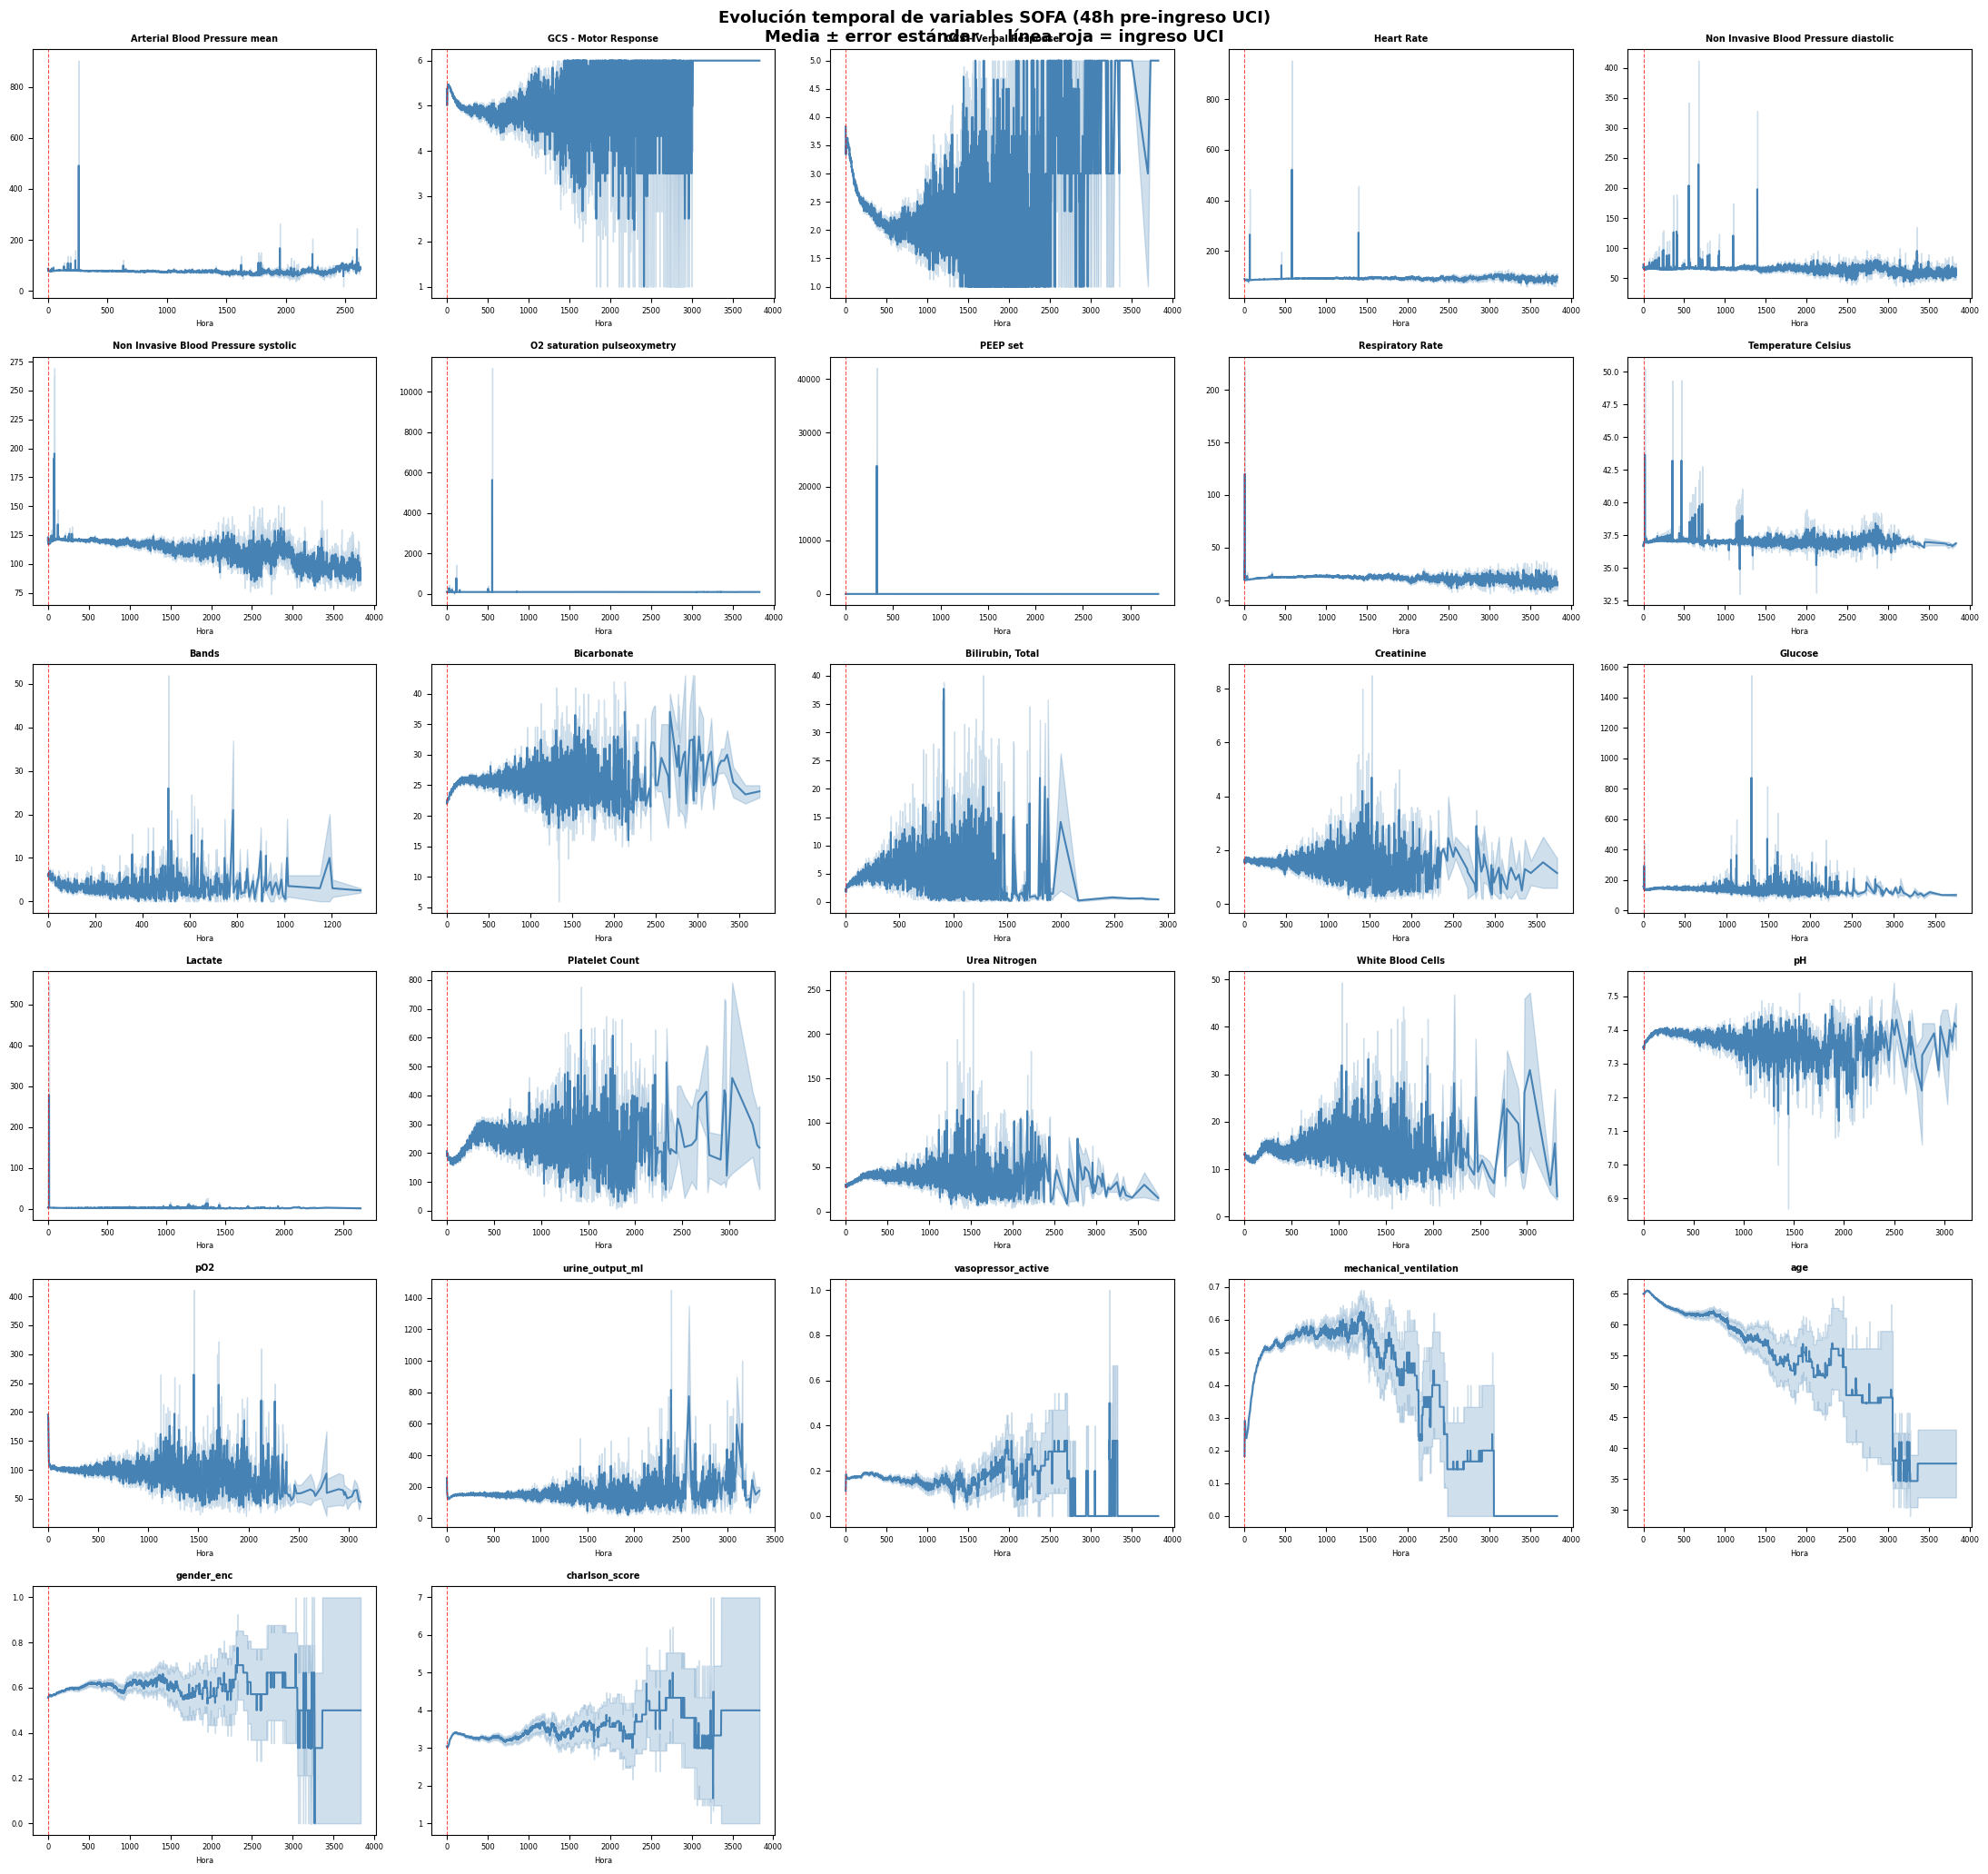

In [25]:
# === Tendencias temporales: media ± error estándar por variable ===
n_features = len(feature_cols)
n_cols = 5
n_rows = (n_features + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    trend = features_df.groupby('hour_bucket')[col].agg(['mean', 'sem']).dropna()
    if trend.empty:
        ax.set_visible(False)
        continue
    ax.plot(trend.index, trend['mean'], color='steelblue', linewidth=1.5)
    ax.fill_between(
        trend.index,
        trend['mean'] - trend['sem'],
        trend['mean'] + trend['sem'],
        alpha=0.25, color='steelblue'
    )
    ax.axvline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='Ingreso UCI')
    ax.set_title(col, fontsize=7, fontweight='bold')
    ax.set_xlabel('Hora', fontsize=6)
    ax.tick_params(labelsize=6)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Evolución temporal de variables SOFA (48h pre-ingreso UCI)\nMedia ± error estándar  |  línea roja = ingreso UCI',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

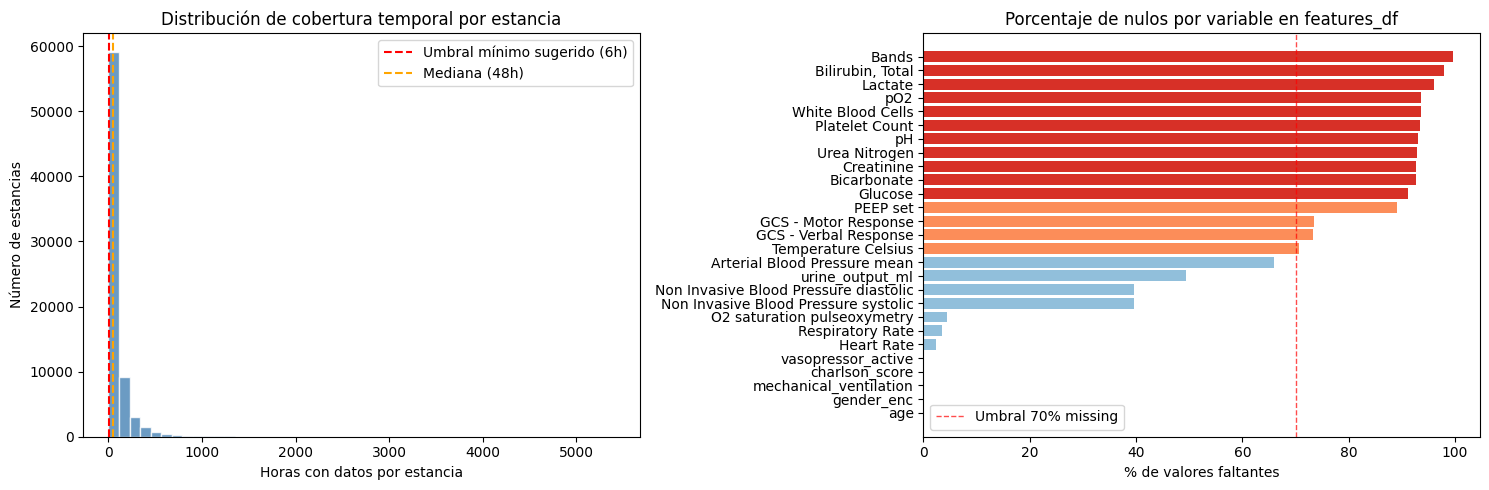


Estancias con >= 6h de datos: 74,263 (99.3%)
Estancias con < 6h de datos:  491 (0.7%)


In [26]:
# === Histograma de cobertura temporal por estancia + % nulos por variable ===
horas_por_estancia = features_df.groupby('stay_id')['hour_bucket'].count()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histograma de horas con datos
ax1.hist(horas_por_estancia, bins=48, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(6, color='red', linestyle='--', linewidth=1.5, label='Umbral mínimo sugerido (6h)')
ax1.axvline(horas_por_estancia.median(), color='orange', linestyle='--', linewidth=1.5,
            label=f'Mediana ({horas_por_estancia.median():.0f}h)')
ax1.set_xlabel('Horas con datos por estancia')
ax1.set_ylabel('Número de estancias')
ax1.set_title('Distribución de cobertura temporal por estancia')
ax1.legend()

# % nulos por variable (barras horizontales)
null_pct_sorted = features_df[feature_cols].isna().mean().sort_values(ascending=True)
colors = ['#d73027' if v > 0.9 else '#fc8d59' if v > 0.7 else '#91bfdb' for v in null_pct_sorted]
ax2.barh(null_pct_sorted.index, null_pct_sorted.values * 100, color=colors)
ax2.axvline(70, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Umbral 70% missing')
ax2.set_xlabel('% de valores faltantes')
ax2.set_title('Porcentaje de nulos por variable en features_df')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nEstancias con >= 6h de datos: {(horas_por_estancia >= 6).sum():,} "
      f"({(horas_por_estancia >= 6).mean()*100:.1f}%)")
print(f"Estancias con < 6h de datos:  {(horas_por_estancia < 6).sum():,} "
      f"({(horas_por_estancia < 6).mean()*100:.1f}%)")

## Exportación

Guardado de la matriz de features final lista para el siguiente paso del pipeline (preprocesado e imputación).

In [27]:
features_df.columns.name = None

FEATURES_ALL_PATH = f'{OUTPUT_DIR}/features_df.parquet'
COHORT_ALL_PATH = f'{OUTPUT_DIR}/cohort_df.parquet'
SOFA_HOURLY_PATH = f'{OUTPUT_DIR}/sofa_hourly.parquet'

# Workaround: evitar bug de PyArrow con extension types (e.g., pandas.period)
for df in [features_df, cohort_all, sofa_hourly]:
    for col in df.columns:
        if pd.api.types.is_period_dtype(df[col]) or pd.api.types.is_interval_dtype(df[col]):
            df[col] = df[col].astype(str)
    df.reset_index(drop=True, inplace=True)

features_df.to_parquet(FEATURES_ALL_PATH, index=False)
cohort_all.to_parquet(COHORT_ALL_PATH, index=False)
sofa_hourly[[ID_STAY, 'h_since_intime', 'sofa']].to_parquet(SOFA_HOURLY_PATH, index=False)

print(f'features_all → {FEATURES_ALL_PATH}')
print(f'cohort_all   → {COHORT_ALL_PATH}')
print(f'Shape features_all: {features_df.shape}')
print(f'Variables: {feature_cols}')
print(f'\nDistribución de labels:')
print(cohort_all['label'].value_counts().to_string())

features_all → ../data/processed/features_df.parquet
cohort_all   → ../data/processed/cohort_df.parquet
Shape features_all: (6821648, 29)
Variables: ['Arterial Blood Pressure mean', 'GCS - Motor Response', 'GCS - Verbal Response', 'Heart Rate', 'Non Invasive Blood Pressure diastolic', 'Non Invasive Blood Pressure systolic', 'O2 saturation pulseoxymetry', 'PEEP set', 'Respiratory Rate', 'Temperature Celsius', 'Bands', 'Bicarbonate', 'Bilirubin, Total', 'Creatinine', 'Glucose', 'Lactate', 'Platelet Count', 'Urea Nitrogen', 'White Blood Cells', 'pH', 'pO2', 'urine_output_ml', 'vasopressor_active', 'mechanical_ventilation', 'age', 'gender_enc', 'charlson_score']

Distribución de labels:
label
1    37377
0    37377
